# Indonesian BERT Email Spam Model Training

This notebook trains a separate Bahasa Indonesia BERT model for the Streamlit app. It keeps the English BERT model unchanged and saves the Indonesian model to `bert_indonesia_spam_model`.

In [3]:
from google.colab import files

# Upload email_spam_indo.csv
uploaded = files.upload()

Saving email_spam_indo.csv to email_spam_indo.csv


In [4]:
!pip install -q transformers datasets accelerate seaborn joblib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("GPU available:", torch.cuda.is_available())

GPU available: True


In [5]:
df = pd.read_csv("email_spam_indo.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print("Missing values:")
print(df.isnull().sum())
print()
print("Class distribution:")
print(df["Kategori"].value_counts())

df.head()

Shape: (2636, 2)
Columns: ['Kategori', 'Pesan']

Missing values:
Kategori    0
Pesan       0
dtype: int64

Class distribution:
Kategori
spam    1368
ham     1268
Name: count, dtype: int64


,Kategori,Pesan
0,spam,Secara alami tak tertahankan identitas perusah...
1,spam,Fanny Gunslinger Perdagangan Saham adalah Merr...
2,spam,Rumah -rumah baru yang luar biasa menjadi muda...
3,spam,4 Permintaan Khusus Pencetakan Warna Informasi...
4,spam,"Jangan punya uang, dapatkan CD perangkat lunak..."


In [6]:
# Expected columns:
# Pesan = email text
# Kategori = ham or spam
label_map = {
    "ham": 0,
    "spam": 1,
}

df["text"] = df["Pesan"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df["label"] = df["Kategori"].fillna("").astype(str).str.lower().str.strip()
df["label_num"] = df["label"].map(label_map)

df = df[
    (df["text"] != "") &
    (df["label_num"].notna())
].copy()

# Remove exact duplicates before splitting.
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
df["label_num"] = df["label_num"].astype(int)
df["label_name"] = df["label_num"].map({0: "ham", 1: "spam"})

print("After cleaning and duplicate removal:", df.shape)
print(df["label_name"].value_counts())

df[["text", "label_name", "label_num"]].head()

After cleaning and duplicate removal: (2620, 6)
label_name
spam    1368
ham     1252
Name: count, dtype: int64


,text,label_name,label_num
0,Secara alami tak tertahankan identitas perusah...,spam,1
1,Fanny Gunslinger Perdagangan Saham adalah Merr...,spam,1
2,Rumah -rumah baru yang luar biasa menjadi muda...,spam,1
3,4 Permintaan Khusus Pencetakan Warna Informasi...,spam,1
4,"Jangan punya uang, dapatkan CD perangkat lunak...",spam,1


In [7]:
# 80% training pool, 20% final test set
train_valid_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label_num"],
)

# 10% of training pool for validation/checkpoint selection
train_df, valid_df = train_test_split(
    train_valid_df,
    test_size=0.10,
    random_state=SEED,
    stratify=train_valid_df["label_num"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training samples:", len(train_df))
print("Validation samples:", len(valid_df))
print("Testing samples:", len(test_df))
print()
print("Training labels:")
print(train_df["label_name"].value_counts())
print()
print("Testing labels:")
print(test_df["label_name"].value_counts())

Training samples: 1886
Validation samples: 210
Testing samples: 524

Training labels:
label_name
spam    984
ham     902
Name: count, dtype: int64

Testing labels:
label_name
spam    274
ham     250
Name: count, dtype: int64


In [8]:
BERT_MODEL_NAME = "bert-base-multilingual-cased"

indo_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=indo_tokenizer)


def make_dataset(dataframe):
    return Dataset.from_dict({
        "text": dataframe["text"].tolist(),
        "labels": dataframe["label_num"].tolist(),
    })


def tokenize_batch(batch):
    return indo_tokenizer(
        batch["text"],
        truncation=True,
        max_length=256,
    )

train_dataset = make_dataset(train_df).map(tokenize_batch, batched=True, remove_columns=["text"])
valid_dataset = make_dataset(valid_df).map(tokenize_batch, batched=True, remove_columns=["text"])
test_dataset = make_dataset(test_df).map(tokenize_batch, batched=True, remove_columns=["text"])

train_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Map:   0%|          | 0/1886 [00:00<?, ? examples/s]

Map:   0%|          | 0/210 [00:00<?, ? examples/s]

Map:   0%|          | 0/524 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1886
})

In [9]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, pos_label=1, zero_division=0),
        "recall": recall_score(labels, predictions, pos_label=1, zero_division=0),
        "f1": f1_score(labels, predictions, pos_label=1, zero_division=0),
    }

In [10]:
indo_model = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME,
    num_labels=2,
    id2label={0: "HAM", 1: "SPAM"},
    label2id={"HAM": 0, "SPAM": 1},
)

training_args = TrainingArguments(
    output_dir="./bert_indonesia_training_output",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=1,
    logging_steps=25,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
)

trainer = Trainer(
    model=indo_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.108112,0.006550,1.000000,1.000000,1.000000,1.000000
2,0.041685,0.003148,1.000000,1.000000,1.000000,1.000000
3,0.000484,0.005063,1.000000,1.000000,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=708, training_loss=0.12087216977514116, metrics={'train_runtime': 179.3552, 'train_samples_per_second': 31.546, 'train_steps_per_second': 3.947, 'total_flos': 743921842368960.0, 'train_loss': 0.12087216977514116, 'epoch': 3.0})

In [11]:
test_output = trainer.predict(test_dataset)
test_logits = test_output.predictions
test_predictions = np.argmax(test_logits, axis=1)
y_test = test_df["label_num"].to_numpy()

metrics = {
    "Model": "Indonesian BERT",
    "Accuracy": accuracy_score(y_test, test_predictions),
    "Precision": precision_score(y_test, test_predictions, pos_label=1, zero_division=0),
    "Recall": recall_score(y_test, test_predictions, pos_label=1, zero_division=0),
    "F1-Score": f1_score(y_test, test_predictions, pos_label=1, zero_division=0),
}

comparison_df = pd.DataFrame([metrics])
for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison_df[column] = comparison_df[column].round(4)

print(classification_report(
    y_test,
    test_predictions,
    target_names=["Ham", "Spam"],
    zero_division=0,
))

comparison_df

              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98       250
        Spam       0.98      0.99      0.99       274

    accuracy                           0.98       524
   macro avg       0.98      0.98      0.98       524
weighted avg       0.98      0.98      0.98       524



,Model,Accuracy,Precision,Recall,F1-Score
0,Indonesian BERT,0.9847,0.9819,0.9891,0.9855


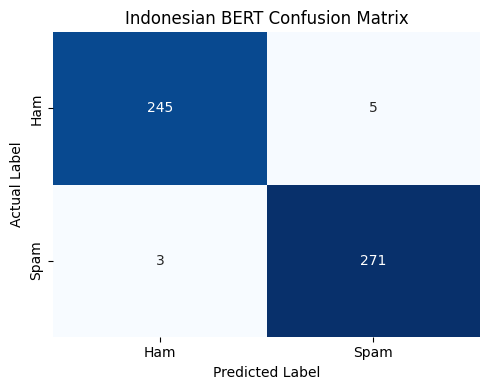

In [12]:
matrix = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(5, 4))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"],
)
plt.title("Indonesian BERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [13]:
os.makedirs("saved_models", exist_ok=True)

INDO_MODEL_DIR = "saved_models/bert_indonesia_spam_model"
trainer.save_model(INDO_MODEL_DIR)
indo_tokenizer.save_pretrained(INDO_MODEL_DIR)

comparison_df.to_csv("saved_models/model_comparison_indonesia.csv", index=False)
df.to_csv("final_preprocessed_indonesia_spam_dataset.csv", index=False)

print("Indonesian model saved to:", INDO_MODEL_DIR)
print("Indonesian comparison saved to: saved_models/model_comparison_indonesia.csv")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Indonesian model saved to: saved_models/bert_indonesia_spam_model
Indonesian comparison saved to: saved_models/model_comparison_indonesia.csv


In [14]:
sample_indo_text = "Peringatan: akun bank Anda akan diblokir dalam 24 jam. Klik tautan ini untuk verifikasi segera."

inputs = indo_tokenizer(
    sample_indo_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256,
)
inputs = {key: value.to(trainer.model.device) for key, value in inputs.items()}

trainer.model.eval()
with torch.no_grad():
    logits = trainer.model(**inputs).logits
    probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()

prediction = int(np.argmax(probabilities))

print("Prediction:", "SPAM" if prediction == 1 else "HAM")
print("Ham probability:", probabilities[0])
print("Spam probability:", probabilities[1])

Prediction: SPAM
Ham probability: 0.006085737
Spam probability: 0.9939143


In [15]:
!zip -r bert_indonesia_spam_model.zip saved_models/bert_indonesia_spam_model

files.download("bert_indonesia_spam_model.zip")
files.download("saved_models/model_comparison_indonesia.csv")
files.download("final_preprocessed_indonesia_spam_dataset.csv")

  adding: saved_models/bert_indonesia_spam_model/ (stored 0%)
  adding: saved_models/bert_indonesia_spam_model/training_args.bin (deflated 53%)
  adding: saved_models/bert_indonesia_spam_model/tokenizer_config.json (deflated 44%)
  adding: saved_models/bert_indonesia_spam_model/tokenizer.json (deflated 67%)
  adding: saved_models/bert_indonesia_spam_model/model.safetensors (deflated 7%)
  adding: saved_models/bert_indonesia_spam_model/config.json (deflated 55%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>